In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
def plot_metric_distribution(df, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(title)
    df["precision"].hist(bins=np.arange(0, 1.2, 0.1), ax=ax[0])
    ax[0].set_title("Precision")
    df["recall"].hist(bins=np.arange(0, 1.2, 0.1), ax=ax[1])
    ax[1].set_title("Recall")
    plt.show()

In [3]:
df = pd.read_csv("../output/20250309233623/result.csv")

In [34]:
df.head()

,instance_id,gold_files,retrieved_files,info,num_gold_files,num_retrieved_files,precision,recall
0,scikit-learn__scikit-learn-13472,['sklearn/ensemble/gradient_boosting.py'],"['sklearn/ensemble/gradient_boosting.py', 'skl...",llm_0,1,2,0.500000,1.0
1,scikit-learn__scikit-learn-13472,['sklearn/ensemble/gradient_boosting.py'],['sklearn/ensemble/gradient_boosting.py'],llm_1,1,1,1.000000,1.0
2,scikit-learn__scikit-learn-13472,['sklearn/ensemble/gradient_boosting.py'],['sklearn/ensemble/gradient_boosting.py'],llm_2,1,1,1.000000,1.0
3,scikit-learn__scikit-learn-13472,['sklearn/ensemble/gradient_boosting.py'],"['sklearn/ensemble/gradient_boosting.py', 'skl...",llm_3,1,2,0.500000,1.0
4,scikit-learn__scikit-learn-13472,['sklearn/ensemble/gradient_boosting.py'],"['sklearn/pipeline.py', 'sklearn/externals/job...",BM25,1,30,0.033333,1.0


In [9]:
batch_size = 4
llm_selection_result_df = df.groupby("instance_id").head(batch_size)
bm25_result_df = df.groupby("instance_id").nth(batch_size)
llm_retrieval_result_df = df.groupby("instance_id").tail(batch_size)

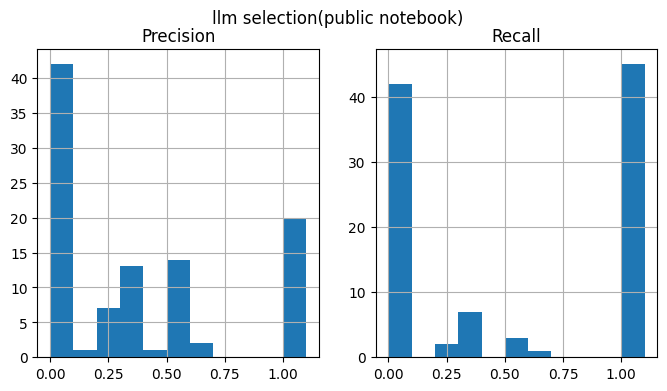

In [26]:
recall_max_selected = llm_selection_result_df.groupby("instance_id").apply(lambda x: x.iloc[x["recall"].argmax()], include_groups=False).reset_index()
plot_metric_distribution(recall_max_selected, title="llm selection(public notebook)")

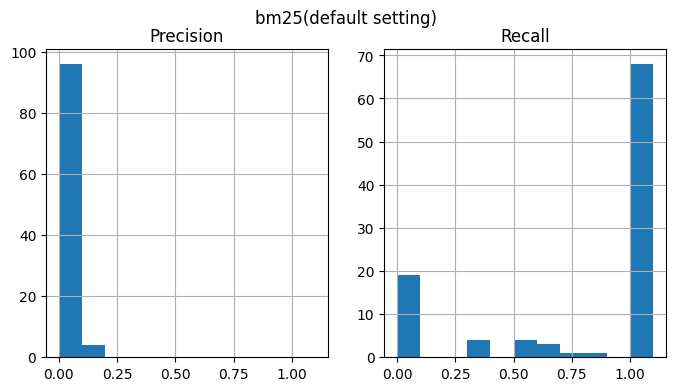

In [27]:
recall_max_selected = bm25_result_df.groupby("instance_id").apply(lambda x: x.iloc[x["recall"].argmax()], include_groups=False).reset_index()
plot_metric_distribution(recall_max_selected, title="bm25(default setting)")

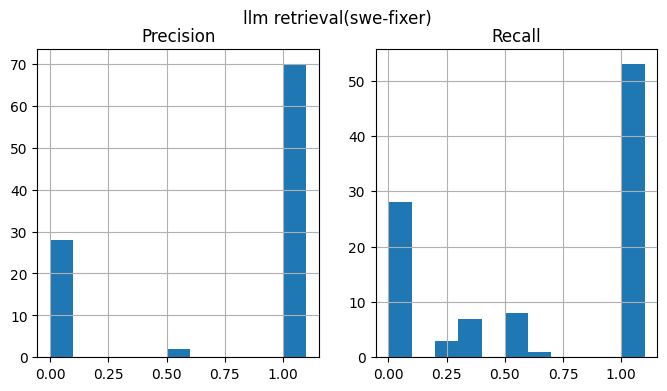

In [28]:
recall_max_selected = llm_retrieval_result_df.groupby("instance_id").apply(lambda x: x.iloc[x["recall"].argmax()], include_groups=False).reset_index()
plot_metric_distribution(recall_max_selected, title="llm retrieval(swe-fixer)")

In [32]:
llm_retrieval_result_df.groupby("instance_id")["recall"].apply(lambda x: x.nunique()).value_counts()

recall
1    73
2    27
Name: count, dtype: int64

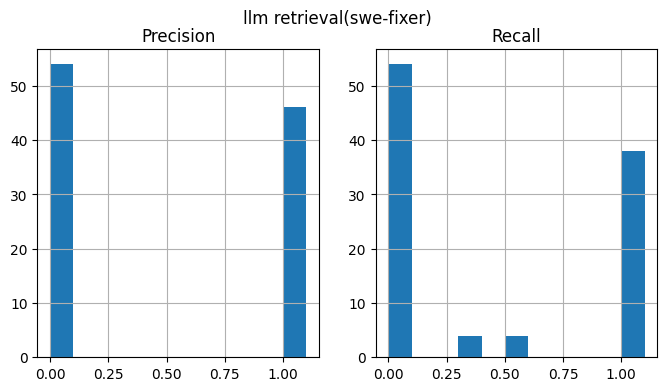

In [33]:
recall_worst_selected = llm_retrieval_result_df.groupby("instance_id").apply(lambda x: x.iloc[x["recall"].argmin()], include_groups=False).reset_index()
plot_metric_distribution(recall_worst_selected, title="llm retrieval(swe-fixer)")

In [37]:
from typing import List
def eval_retrieval(gold_files: List[str], retrieved_files: List[str]) -> dict:
    # precision, recall, MAP@30を計算
    retrieved_set = set(retrieved_files)
    gold_set = set(gold_files)

    # Precision
    true_positives = len(retrieved_set & gold_set)
    precision = true_positives / len(retrieved_set) if retrieved_set else 0

    # Recall
    recall = true_positives / len(gold_set) if gold_set else 0

    # MAP@30
    average_precision = 0
    relevant_docs_found = 0
    for i, file in enumerate(retrieved_files[:30]):
        if file in gold_set:
            relevant_docs_found += 1
            average_precision += relevant_docs_found / (i + 1)
    map_30 = average_precision / min(len(gold_set), 30) if gold_set else 0

    return {
        "num_gold_files": len(gold_files),
        "num_retrieved_files": len(retrieved_files),
        "precision": precision,
        "recall": recall,
        "map_30": map_30,
        }

In [40]:
retrieved_files

nan

In [48]:
import ast
llm_retrieval_combined = llm_retrieval_result_df.groupby("instance_id").nth(0).set_index("instance_id").copy()
llm_retrieval_combined["retrieved_files"] = llm_retrieval_result_df.groupby("instance_id")["retrieved_files"].apply(lambda x: list(set(sum(x.apply(ast.literal_eval).tolist(), []))))
llm_retrieval_combined["gold_files"] = llm_retrieval_combined["gold_files"].apply(ast.literal_eval)
for i, row in llm_retrieval_combined.iterrows():
    gold_files = row["gold_files"]
    retrieved_files = row["retrieved_files"]
    llm_retrieval_combined["num_retrieved_files"].at[i] = len(retrieved_files)
    result = eval_retrieval(gold_files, retrieved_files)
    for key, value in result.items():
        llm_retrieval_combined.at[i, key] = value

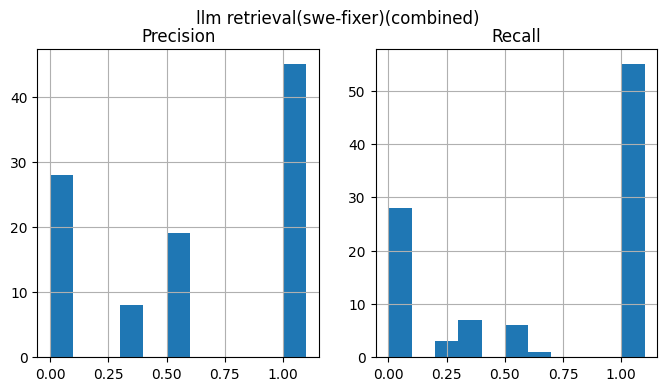

In [50]:
plot_metric_distribution(llm_retrieval_combined, title="llm retrieval(swe-fixer)(combined)")

<Axes: >

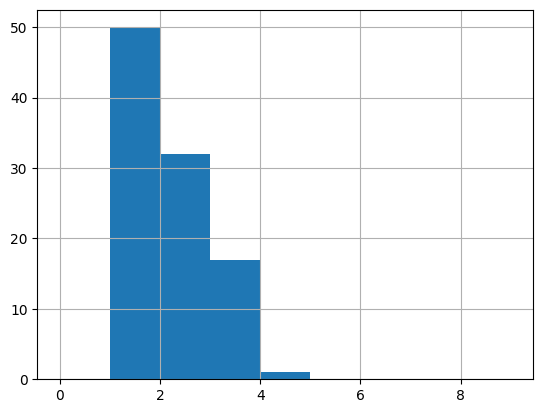

In [ ]:
ax = llm_retrieval_combined["num_retrieved_files"].hist(bins=np.arange(0, 10, 1))